<a href="https://colab.research.google.com/github/Adhithyanrajesh/Generative-AI-internship-/blob/main/Image_preprocessingday4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

path = kagglehub.dataset_download("anthonytherrien/dog-vs-cat")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-vs-cat' dataset.
Path to dataset files: /kaggle/input/dog-vs-cat


Contents of the dataset path '/kaggle/input/dog-vs-cat':
- animals
Attempting to load images from: /kaggle/input/dog-vs-cat/animals/cat


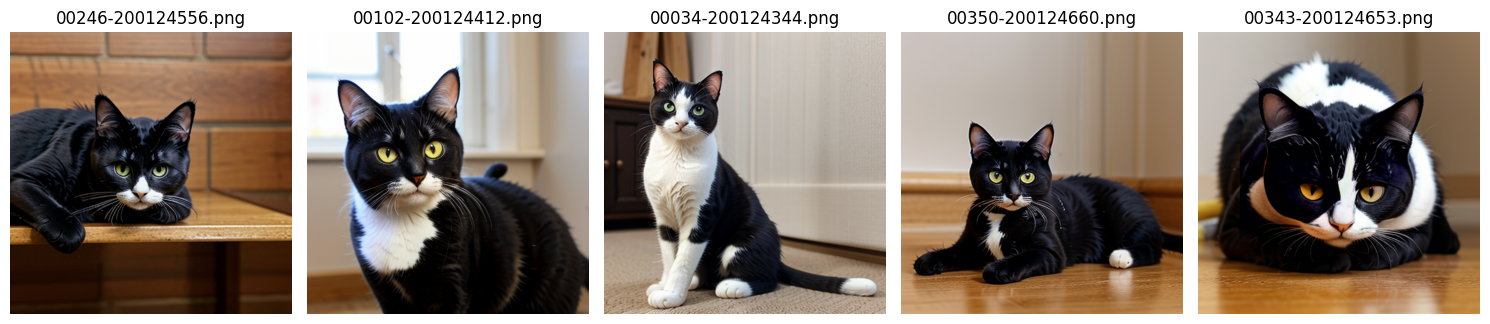

In [5]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Print contents of the base path to understand the directory structure
print(f"Contents of the dataset path '{path}':")
try:
    path_contents = os.listdir(path)
    for item in path_contents:
        print(f"- {item}")
except FileNotFoundError:
    print(f"Error: Base path '{path}' not found. This indicates an issue with dataset download or path variable.")
    raise # Re-raise to indicate a fundamental problem

# Based on the observed structure, the images are in 'animals/cat' and 'animals/dog'
# Let's target the 'animals/cat' directory for visualization

image_dir = os.path.join(path, 'animals', 'cat')

print(f"Attempting to load images from: {image_dir}")

# List all files in the image directory
try:
    # Added common capitalized extensions as well
    image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
except FileNotFoundError:
    print(f"Error: The identified image directory '{image_dir}' does not exist or is not accessible.")
    raise # Re-raise to stop execution

# Select the first 5 images to display, or fewer if not enough are available
images_to_display = image_files[:5]

if not images_to_display:
    print(f"No image files (jpg, jpeg, png) found in {image_dir}. Please check the directory content or file extensions.")
else:
    plt.figure(figsize=(15, 5))
    for i, img_name in enumerate(images_to_display):
        img_path = os.path.join(image_dir, img_name)
        img = mpimg.imread(img_path)

        plt.subplot(1, len(images_to_display), i + 1)
        plt.imshow(img)
        plt.title(img_name)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [6]:
import pandas as pd

image_data = []

# Assuming image_dir and image_files are already defined from the previous cell
# If not, ensure they are correctly set up or redefine them here.
# For example:
# image_dir = os.path.join(path, 'animals', 'cat')
# image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Iterate through all image files to extract dimensions
for img_name in image_files:
    img_path = os.path.join(image_dir, img_name)
    img = mpimg.imread(img_path)

    height, width, channels = img.shape
    image_data.append({
        'filename': img_name,
        'height': height,
        'width': width,
        'channels': channels
    })

# Create a pandas DataFrame from the extracted data
image_dimensions_df = pd.DataFrame(image_data)

print(f"Extracted dimensions for {len(image_files)} images.")
print("First 5 rows of the image dimensions table:")
display(image_dimensions_df.head())

Extracted dimensions for 500 images.
First 5 rows of the image dimensions table:


,filename,height,width,channels
0,00246-200124556.png,512,512,3
1,00102-200124412.png,512,512,3
2,00034-200124344.png,512,512,3
3,00350-200124660.png,512,512,3
4,00343-200124653.png,512,512,3


In [7]:
from PIL import Image
import shutil

# Define source and destination directories
source_cat_dir = os.path.join(path, 'animals', 'cat')
source_dog_dir = os.path.join(path, 'animals', 'dog')

output_base_dir = 'resized_images'
output_cat_dir = os.path.join(output_base_dir, 'cat')
output_dog_dir = os.path.join(output_base_dir, 'dog')

# Create output directories if they don't exist
os.makedirs(output_cat_dir, exist_ok=True)
os.makedirs(output_dog_dir, exist_ok=True)

# Target size for resizing
TARGET_SIZE = (224, 224)

print(f"Resizing images to {TARGET_SIZE[0]}x{TARGET_SIZE[1]} pixels...")

def resize_and_save_images(source_dir, dest_dir):
    resized_image_data = []
    image_files_in_dir = [f for f in os.listdir(source_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"  Processing {len(image_files_in_dir)} images from {source_dir}")
    for img_name in image_files_in_dir:
        img_path = os.path.join(source_dir, img_name)
        output_path = os.path.join(dest_dir, img_name)
        try:
            img = Image.open(img_path)
            img_resized = img.resize(TARGET_SIZE)
            img_resized.save(output_path)
            resized_image_data.append({
                'filename': img_name,
                'category': os.path.basename(source_dir),
                'height': TARGET_SIZE[0],
                'width': TARGET_SIZE[1],
                'channels': 3 # Assuming color images, as most will be.
            })
        except Exception as e:
            print(f"    Error processing {img_name}: {e}")
    return resized_image_data

all_resized_data = []
all_resized_data.extend(resize_and_save_images(source_cat_dir, output_cat_dir))
all_resized_data.extend(resize_and_save_images(source_dog_dir, output_dog_dir))

resized_image_dimensions_df = pd.DataFrame(all_resized_data)

print(f"Successfully resized and saved {len(resized_image_dimensions_df)} images to '{output_base_dir}'")
print("First 5 rows of the resized image dimensions table:")
display(resized_image_dimensions_df.head())

Resizing images to 224x224 pixels...
  Processing 500 images from /kaggle/input/dog-vs-cat/animals/cat
  Processing 500 images from /kaggle/input/dog-vs-cat/animals/dog
Successfully resized and saved 1000 images to 'resized_images'
First 5 rows of the resized image dimensions table:


,filename,category,height,width,channels
0,00246-200124556.png,cat,224,224,3
1,00102-200124412.png,cat,224,224,3
2,00034-200124344.png,cat,224,224,3
3,00350-200124660.png,cat,224,224,3
4,00343-200124653.png,cat,224,224,3


### Convert images to Grayscale, RGB, and HSV

Using sample image: resized_images/cat/00246-200124556.png


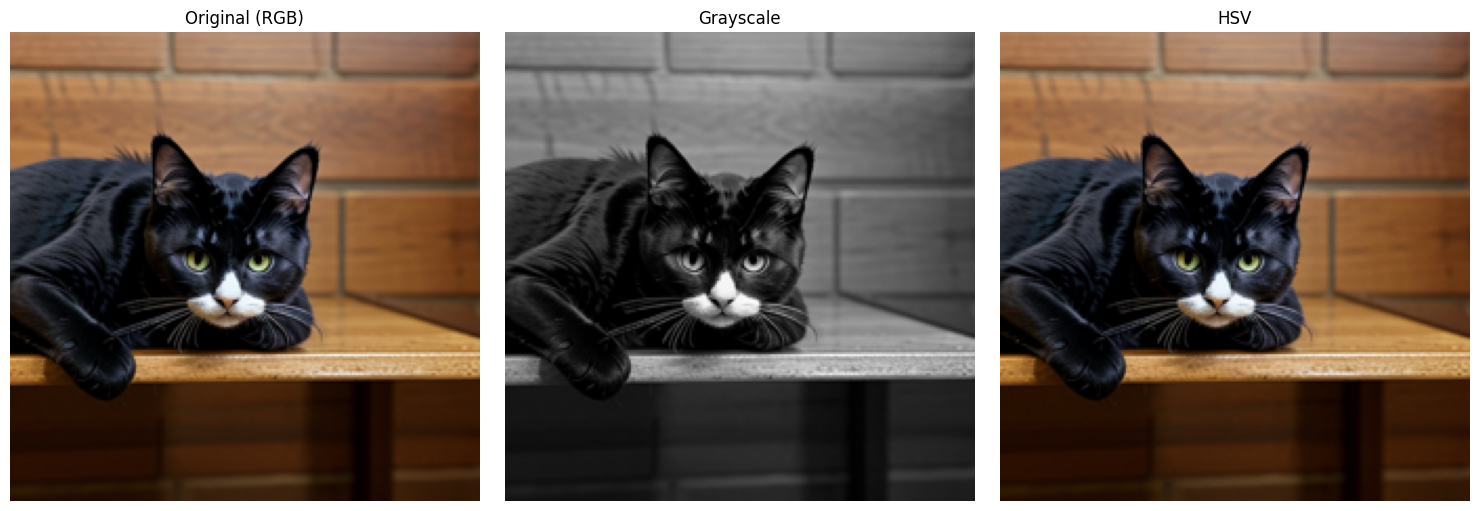

In [8]:
import cv2

# Get a sample image path from the resized images
if not resized_image_dimensions_df.empty:
    sample_filename = resized_image_dimensions_df.iloc[0]['filename']
    sample_category = resized_image_dimensions_df.iloc[0]['category']
    sample_image_path = os.path.join('resized_images', sample_category, sample_filename)
    print(f"Using sample image: {sample_image_path}")
else:
    print("No resized images found to pick a sample from. Please ensure the previous step ran correctly.")
    raise FileNotFoundError("Could not find any resized images.")

# Load the image using OpenCV (as PIL doesn't directly handle HSV conversion easily from RGB)
# OpenCV reads images as BGR by default
img_bgr = cv2.imread(sample_image_path)

# Check if image was loaded correctly
if img_bgr is None:
    print(f"Error: Could not load image at {sample_image_path}")
    raise ValueError("Image not loaded.")

# Convert BGR to RGB for consistent display and further processing with other libraries
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Convert to Grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Convert to HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Display the images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Original (RGB)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(1, 3, 3)
# For HSV, we need to convert it back to RGB for matplotlib to display correctly
plt.imshow(cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB))
plt.title('HSV')
plt.axis('off')

plt.tight_layout()
plt.show()

### Normalize Pixel Values

### Data Augmentation

Using sample image for augmentation: resized_images/cat/00246-200124556.png


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


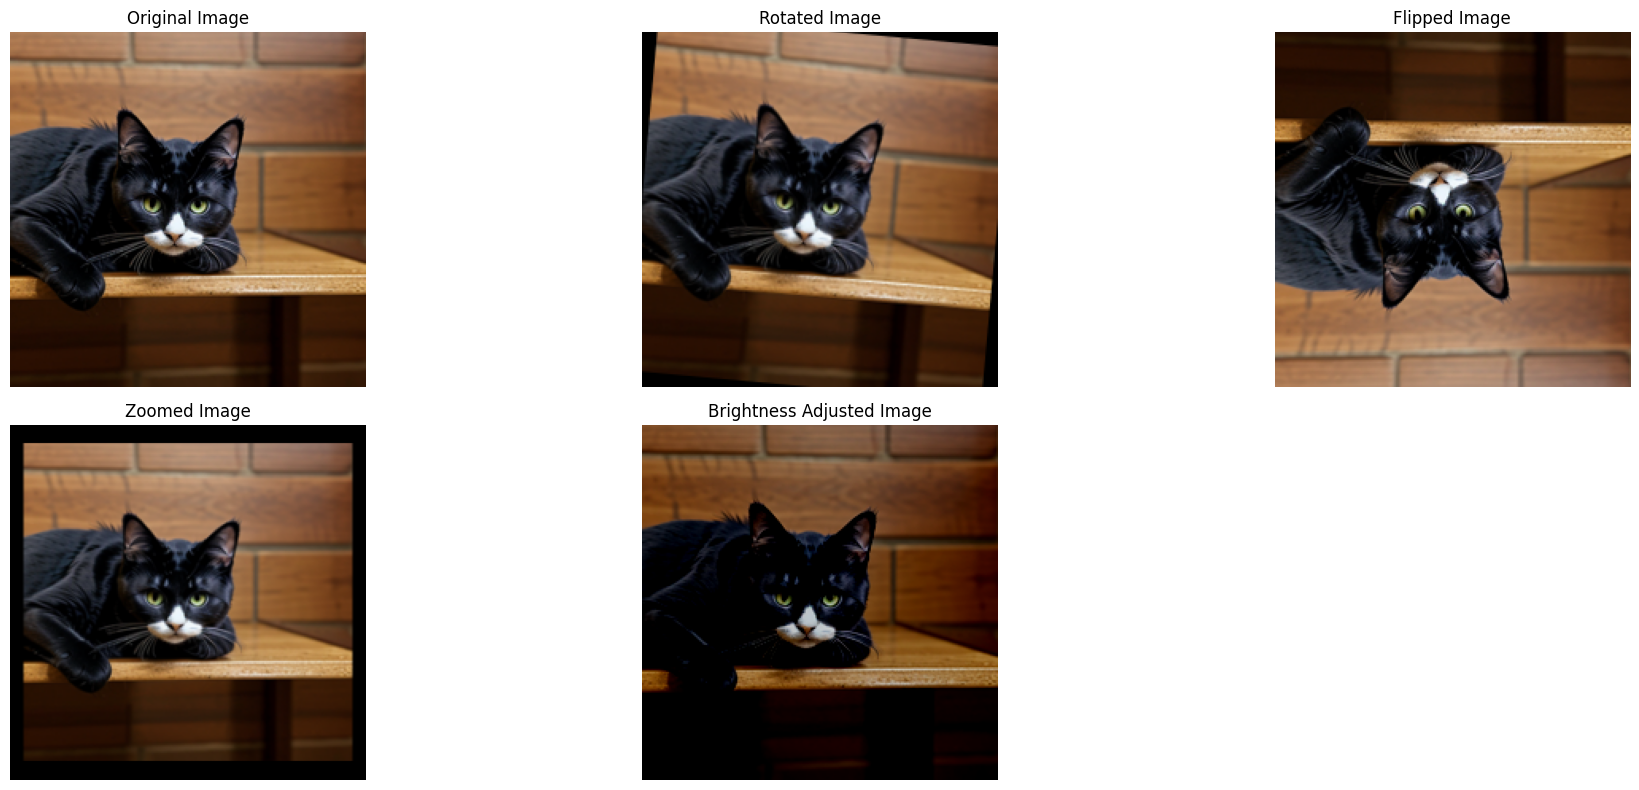

In [10]:
# Install albumentations for advanced image augmentation
!pip install albumentations -qq

import albumentations as A

# Get a sample image (using the normalized RGB image from the previous step for consistency)
# We will reload the original BGR image to apply augmentations, then convert and normalize.
if not resized_image_dimensions_df.empty:
    sample_filename_aug = resized_image_dimensions_df.iloc[0]['filename']
    sample_category_aug = resized_image_dimensions_df.iloc[0]['category']
    sample_image_path_aug = os.path.join('resized_images', sample_category_aug, sample_filename_aug)
    print(f"Using sample image for augmentation: {sample_image_path_aug}")
else:
    print("No resized images found to pick a sample from. Please ensure the previous step ran correctly.")
    raise FileNotFoundError("Could not find any resized images.")

# Load the image in RGB format (albumentations expects RGB)
original_image_bgr = cv2.imread(sample_image_path_aug)
original_image_rgb = cv2.cvtColor(original_image_bgr, cv2.COLOR_BGR2RGB)

# Define different augmentation pipelines
# Rotation
augment_rotate = A.Compose([
    A.Rotate(limit=45, p=1.0) # Rotate by up to 45 degrees
])

# Flips (Horizontal and Vertical)
augment_flips = A.Compose([
    A.HorizontalFlip(p=0.5), # 50% chance of horizontal flip
    A.VerticalFlip(p=0.5)    # 50% chance of vertical flip
])

# Zoom (using RandomResizedCrop or ShiftScaleRotate to simulate zoom)
# ShiftScaleRotate is good for simulating zoom (scale), rotation, and shifts
augment_zoom = A.Compose([
    A.ShiftScaleRotate(shift_limit=0.0, scale_limit=0.2, rotate_limit=0, p=1.0)
])

# Brightness Adjustment
augment_brightness = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0, p=1.0) # Adjust brightness
])

# Apply augmentations
augmented_rotate = augment_rotate(image=original_image_rgb)['image']
augmented_flips = augment_flips(image=original_image_rgb)['image']
augmented_zoom = augment_zoom(image=original_image_rgb)['image']
augmented_brightness = augment_brightness(image=original_image_rgb)['image']

# Display the original and augmented images
plt.figure(figsize=(20, 8))

plt.subplot(2, 3, 1)
plt.imshow(original_image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(augmented_rotate)
plt.title('Rotated Image')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(augmented_flips)
plt.title('Flipped Image')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(augmented_zoom)
plt.title('Zoomed Image')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(augmented_brightness)
plt.title('Brightness Adjusted Image')
plt.axis('off')

plt.tight_layout()
plt.show()

Using sample image for normalization: resized_images/cat/00246-200124556.png


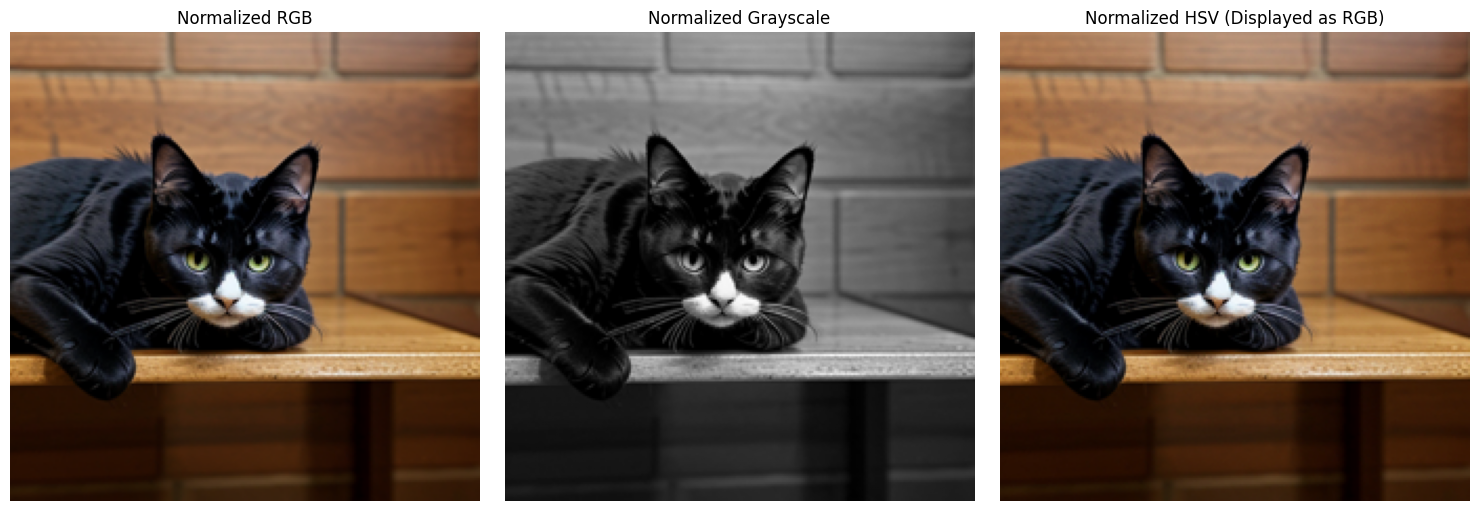


Sample of Normalized RGB image pixel values (first 5x5 block):
[[0.69803923 0.69411767 0.69411767 0.69803923 0.69803923]
 [0.6862745  0.6862745  0.68235296 0.68235296 0.68235296]
 [0.6666667  0.6666667  0.6627451  0.65882355 0.65882355]
 [0.654902   0.654902   0.654902   0.6509804  0.654902  ]
 [0.6627451  0.6627451  0.6666667  0.6627451  0.67058825]]

Sample of Normalized Grayscale image pixel values (first 5x5 block):
[[0.5372549  0.5372549  0.5372549  0.5411765  0.54509807]
 [0.53333336 0.53333336 0.5254902  0.53333336 0.5294118 ]
 [0.5137255  0.5137255  0.50980395 0.50980395 0.50980395]
 [0.5019608  0.5019608  0.5019608  0.5019608  0.5058824 ]
 [0.50980395 0.50980395 0.50980395 0.50980395 0.5176471 ]]

Sample of Normalized HSV image pixel values (first 5x5 block, Hue channel):
[[0.06703911 0.0726257  0.0726257  0.0726257  0.0726257 ]
 [0.0726257  0.0726257  0.06703911 0.0726257  0.0726257 ]
 [0.0726257  0.0726257  0.0726257  0.0726257  0.0726257 ]
 [0.0726257  0.0726257  0.0726257

In [9]:
# Function to load, convert, and normalize an image
def process_and_normalize_image(image_path):
    # Load the image using OpenCV (as BGR)
    img_bgr = cv2.imread(image_path)

    if img_bgr is None:
        print(f"Error: Could not load image at {image_path}")
        return None, None, None # Return None for all if image loading fails

    # Convert BGR to RGB and normalize
    img_rgb_normalized = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    # Convert to Grayscale and normalize
    img_gray_normalized = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

    # Convert to HSV (OpenCV HSV values are typically H:0-179, S:0-255, V:0-255)
    # Normalizing HSV components separately or as a whole depends on the downstream task.
    # For display, we can normalize V and S to 0-1 and H to 0-1 (by dividing by 179 for H and 255 for S,V)
    img_hsv_raw = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_hsv_normalized = img_hsv_raw.astype(np.float32)
    img_hsv_normalized[:, :, 0] /= 179.0  # Normalize Hue
    img_hsv_normalized[:, :, 1] /= 255.0  # Normalize Saturation
    img_hsv_normalized[:, :, 2] /= 255.0  # Normalize Value

    return img_rgb_normalized, img_gray_normalized, img_hsv_normalized

# Get a sample image path from the resized images
if not resized_image_dimensions_df.empty:
    sample_filename_normalized = resized_image_dimensions_df.iloc[0]['filename']
    sample_category_normalized = resized_image_dimensions_df.iloc[0]['category']
    sample_image_path_normalized = os.path.join('resized_images', sample_category_normalized, sample_filename_normalized)
    print(f"Using sample image for normalization: {sample_image_path_normalized}")
else:
    print("No resized images found to pick a sample from. Please ensure the previous step ran correctly.")
    raise FileNotFoundError("Could not find any resized images.")

import numpy as np
# Process the sample image
rgb_norm, gray_norm, hsv_norm = process_and_normalize_image(sample_image_path_normalized)

if rgb_norm is not None:
    # Display the normalized images
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb_norm)
    plt.title('Normalized RGB')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(gray_norm, cmap='gray')
    plt.title('Normalized Grayscale')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    # For HSV, matplotlib can display it if it's converted back to RGB or if V is displayed directly.
    # To display normalized HSV as color, we convert it back to RGB for display purposes
    # Note: cv2.cvtColor expects H to be 0-179, S,V to be 0-255. So, for display, we need to scale back before conversion.
    hsv_display = hsv_norm.copy()
    hsv_display[:, :, 0] *= 179.0
    hsv_display[:, :, 1] *= 255.0
    hsv_display[:, :, 2] *= 255.0
    plt.imshow(cv2.cvtColor(hsv_display.astype(np.uint8), cv2.COLOR_HSV2RGB))
    plt.title('Normalized HSV (Displayed as RGB)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("\nSample of Normalized RGB image pixel values (first 5x5 block):")
    print(rgb_norm[:5, :5, 0]) # Displaying only the Red channel for brevity
    print("\nSample of Normalized Grayscale image pixel values (first 5x5 block):")
    print(gray_norm[:5, :5])
    print("\nSample of Normalized HSV image pixel values (first 5x5 block, Hue channel):")
    print(hsv_norm[:5, :5, 0])


### Create a Reusable `preprocess_image()` Function

This function will encapsulate all the image preprocessing steps:
1.  **Loading**: Reads the image from the specified path.
2.  **Resizing**: Resizes the image to a target dimension (e.g., 224x224 pixels).
3.  **Optional Augmentation**: Applies a predefined set of augmentations (rotation, flips, brightness, contrast, zoom) if requested, primarily for training data.
4.  **Color Space Conversion**: Converts the image into RGB, Grayscale, and HSV color spaces.
5.  **Normalization**: Scales pixel values to a 0-1 range for all three color spaces.

In [11]:
import cv2
import numpy as np
import albumentations as A

def preprocess_image(image_path, target_size=(224, 224), apply_augmentation=False, augmentation_pipeline=None):
    """
    Loads, resizes, optionally augments, converts to multiple color spaces, and normalizes an image.

    Args:
        image_path (str): Path to the image file.
        target_size (tuple, optional): Desired (width, height) for resizing. Defaults to (224, 224).
        apply_augmentation (bool, optional): Whether to apply data augmentation. Defaults to False.
        augmentation_pipeline (albumentations.Compose, optional): Augmentation pipeline to apply if `apply_augmentation` is True.
                                                          If None, a default pipeline is used.

    Returns:
        tuple: (normalized_rgb, normalized_gray, normalized_hsv, augmented_rgb_normalized_if_applied).
               Returns (None, None, None, None) if image loading fails.
    """
    # Load the image using OpenCV (as BGR)
    img_bgr = cv2.imread(image_path)

    if img_bgr is None:
        print(f"Error: Could not load image at {image_path}")
        return None, None, None, None

    # Resize the image
    img_resized_bgr = cv2.resize(img_bgr, target_size)

    # Convert to RGB for consistency and potential augmentation
    img_rgb = cv2.cvtColor(img_resized_bgr, cv2.COLOR_BGR2RGB)

    augmented_rgb = None
    if apply_augmentation:
        if augmentation_pipeline is None:
            # Define a default augmentation pipeline if none is provided
            augmentation_pipeline = A.Compose([
                A.Rotate(limit=30, p=0.7),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.3),
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7),
                A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.5)
            ])
        augmented_rgb = augmentation_pipeline(image=img_rgb)['image']

    # Use the augmented image if available, otherwise the original resized RGB for normalization
    image_for_normalization = augmented_rgb if augmented_rgb is not None else img_rgb

    # Normalize RGB (0-255 to 0-1)
    img_rgb_normalized = image_for_normalization.astype(np.float32) / 255.0

    # Convert to Grayscale from the *original* resized BGR and normalize
    img_gray_normalized = cv2.cvtColor(img_resized_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

    # Convert to HSV from the *original* resized BGR and normalize
    img_hsv_raw = cv2.cvtColor(img_resized_bgr, cv2.COLOR_BGR2HSV)
    img_hsv_normalized = img_hsv_raw.astype(np.float32)
    img_hsv_normalized[:, :, 0] /= 179.0  # Normalize Hue (0-179 to 0-1)
    img_hsv_normalized[:, :, 1] /= 255.0  # Normalize Saturation (0-255 to 0-1)
    img_hsv_normalized[:, :, 2] /= 255.0  # Normalize Value (0-255 to 0-1)

    return img_rgb_normalized, img_gray_normalized, img_hsv_normalized, augmented_rgb

### Demonstrate `preprocess_image()` Function

Using sample image for preprocessing: resized_images/cat/00056-200124366.png

--- Preprocessing without Augmentation ---


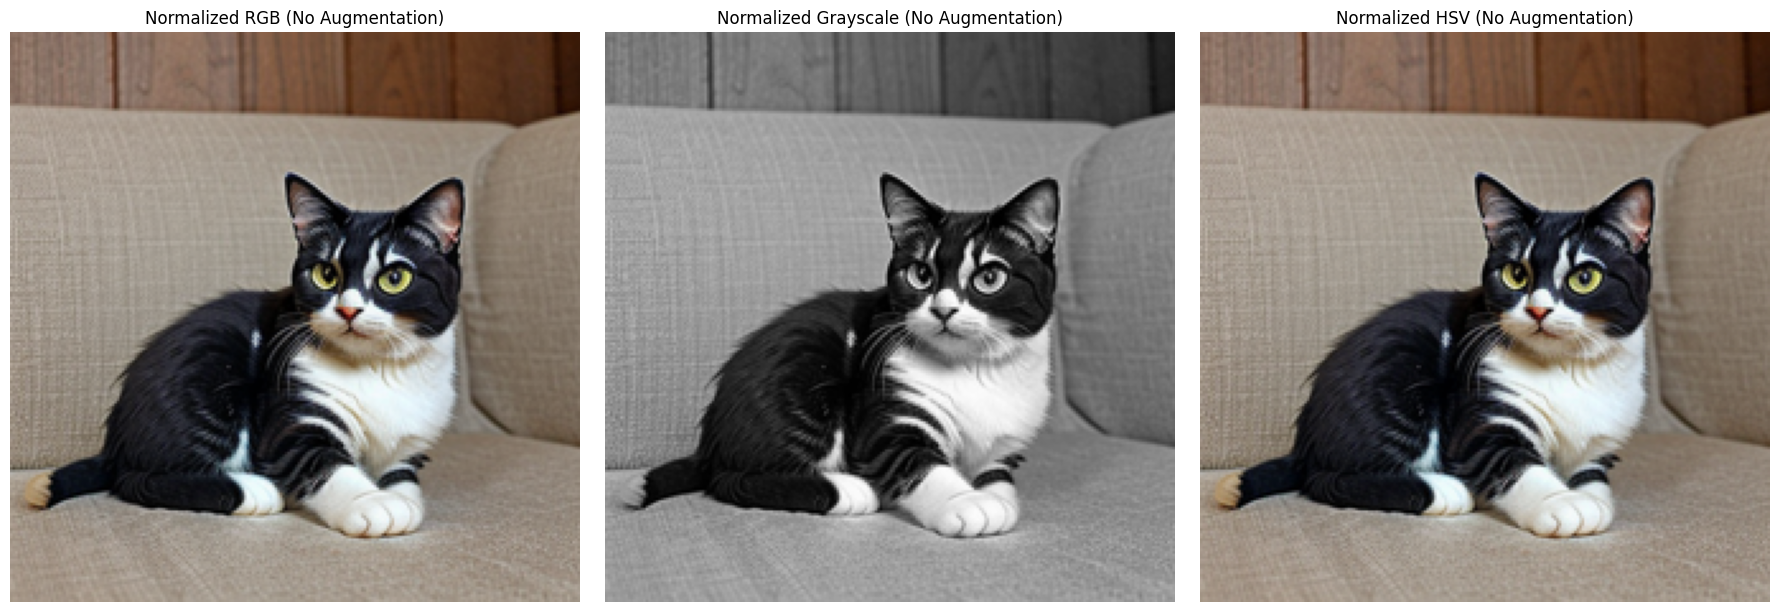


--- Preprocessing with Augmentation ---


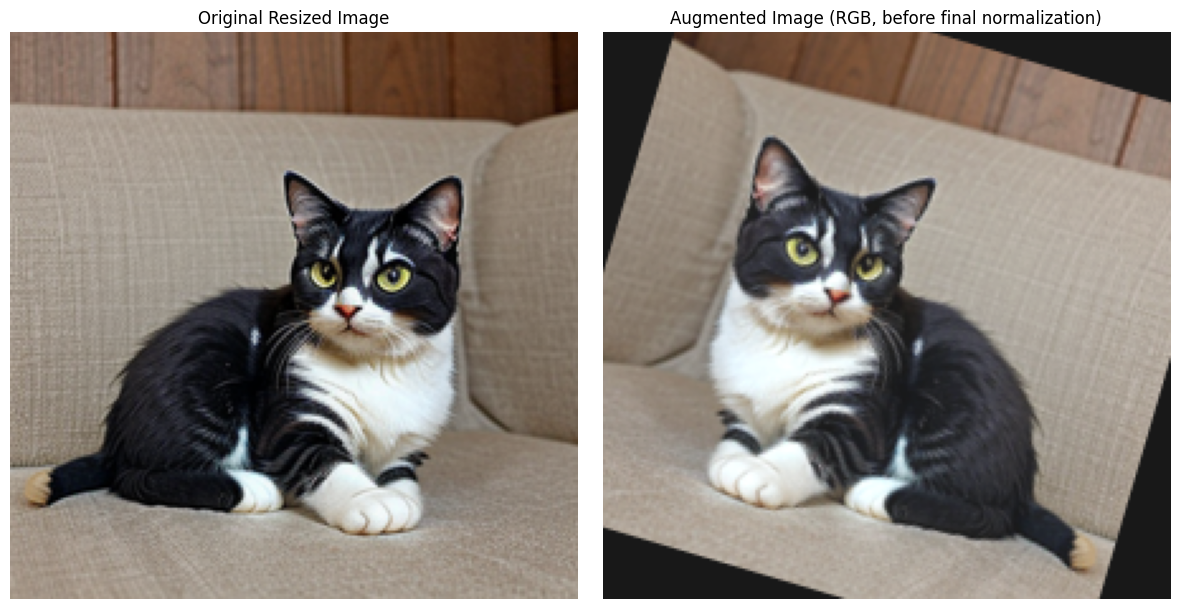


Sample of Normalized RGB image pixel values (first 5x5 block) with augmentation:
[[0.09411765 0.09411765 0.09411765 0.09411765 0.09411765]
 [0.09411765 0.09411765 0.09411765 0.09411765 0.09411765]
 [0.09411765 0.09411765 0.09411765 0.09411765 0.09411765]
 [0.09411765 0.09411765 0.09411765 0.09411765 0.09411765]
 [0.09411765 0.09411765 0.09411765 0.09411765 0.09411765]]


In [12]:
import matplotlib.pyplot as plt

# Get a sample image path from the resized images DataFrame
if not resized_image_dimensions_df.empty:
    sample_filename_preproc = resized_image_dimensions_df.iloc[10]['filename'] # Pick a different sample for variety
    sample_category_preproc = resized_image_dimensions_df.iloc[10]['category']
    sample_image_path_preproc = os.path.join('resized_images', sample_category_preproc, sample_filename_preproc)
    print(f"Using sample image for preprocessing: {sample_image_path_preproc}")
else:
    print("No resized images found to pick a sample from. Please ensure previous steps ran correctly.")
    raise FileNotFoundError("Could not find any resized images.")

# --- Example 1: Preprocessing without augmentation ---
print("\n--- Preprocessing without Augmentation ---")
rgb_norm_no_aug, gray_norm_no_aug, hsv_norm_no_aug, _ = preprocess_image(sample_image_path_preproc, apply_augmentation=False)

if rgb_norm_no_aug is not None:
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(rgb_norm_no_aug)
    plt.title('Normalized RGB (No Augmentation)')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(gray_norm_no_aug, cmap='gray')
    plt.title('Normalized Grayscale (No Augmentation)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    # Convert normalized HSV back to displayable RGB for matplotlib
    hsv_display_no_aug = hsv_norm_no_aug.copy()
    hsv_display_no_aug[:, :, 0] *= 179.0
    hsv_display_no_aug[:, :, 1] *= 255.0
    hsv_display_no_aug[:, :, 2] *= 255.0
    plt.imshow(cv2.cvtColor(hsv_display_no_aug.astype(np.uint8), cv2.COLOR_HSV2RGB))
    plt.title('Normalized HSV (No Augmentation)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- Example 2: Preprocessing with augmentation ---
print("\n--- Preprocessing with Augmentation ---")
# You can define a custom augmentation pipeline here, or use the default one in the function
custom_augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=25, p=1.0),
    A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=1.0)
])

rgb_norm_aug, _, _, augmented_rgb_image = preprocess_image(sample_image_path_preproc, apply_augmentation=True, augmentation_pipeline=custom_augmentation_pipeline)

if rgb_norm_aug is not None:
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    # To display the original (before augmentation) for comparison, we need to reload it
    original_resized_rgb = cv2.cvtColor(cv2.resize(cv2.imread(sample_image_path_preproc), (224, 224)), cv2.COLOR_BGR2RGB)
    plt.imshow(original_resized_rgb)
    plt.title('Original Resized Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    # The `augmented_rgb_image` returned by the function is in 0-255 range and is the raw augmented image
    plt.imshow(augmented_rgb_image)
    plt.title('Augmented Image (RGB, before final normalization)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("\nSample of Normalized RGB image pixel values (first 5x5 block) with augmentation:")
    print(rgb_norm_aug[:5, :5, 0])